---
# TP2 – Analyse en composantes principales, classification et reconstruction
---

---

**Nom : DIALLO**  
**Prénom : Mamadou djouldé**  
**Cursus : M1 SysCom**


--- 

---
## I. Chargement et mise en forme des données

On utilisera les mêmes données que lors du TP1 avec leur redimensionnement et leur mise en 
forme.

- Import des bibliothèques nécessaires

In [82]:
import time
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.decomposition import PCA 

- Fonctions du pré-programme

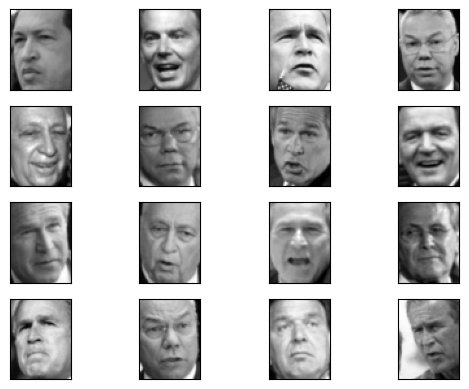

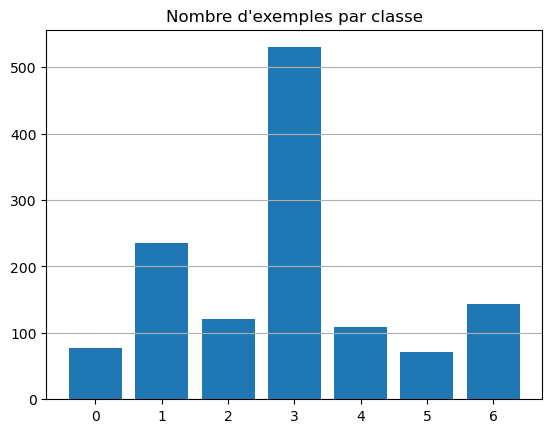

In [84]:
def plotGallery(images, n=16, title=None):
    # Affiche les n premières images contenues dans images
    # images est de taille Nb image*Ny*Nx
    n = min(n, images.shape[0])
    nSubplots = int(np.ceil(np.sqrt(n)))
    fig, axs = plt.subplots(nSubplots, nSubplots)
    for i in range(n):
        axs[i // nSubplots, i % nSubplots].imshow(images[i], cmap=plt.cm.gray)
        axs[i // nSubplots, i % nSubplots].set_xticks([])
        axs[i // nSubplots, i % nSubplots].set_yticks([])
    if title:
        plt.suptitle(title)
    plt.show()

def plotHistoClasses(lbls):
    # Affiche le nombre d'exemples par classe
    nLbls = np.array([[i, np.where(lbls == i)[0].shape[0]] for i in np.unique(lbls)])
    plt.figure()
    plt.bar(nLbls[:, 0], nLbls[:, 1])
    plt.title("Nombre d'exemples par classe")
    plt.grid(axis='y')
    plt.show()

[X, y, name]=np.load("TP2.npy",allow_pickle=True)
plotGallery(X)

plotHistoClasses(y)

- Import de mes differentes fonctions du fichier TP2_ETU.py

In [86]:
from TP2_ETU import partitionner_et_afficher, redimensionnement, acp_max_composantes,classification_5ppv, ACP_n_composants, vecteur_propre_en_image_propre

 #### Données en apprentissage et en test : 

In [88]:
X_train, X_test, y_train, y_test = partitionner_et_afficher(X, y)


Données en apprentissage et en test :
Nombre d'images en apprentissage : 966
Nombre d'images en test : 322


#### Dimension des données après redimensionnement : 

In [90]:
X_train, X_test = redimensionnement(X_train, X_test)


Après redimensionnement :
Dimensions de X_train : (966, 2914)
Dimensions de X_test : (322, 2914)


---
### Reponses I :  
- Données en apprentissage et en test :

    Nombre d'images en apprentissage : 966

    Nombre d'images en test : 322
        
- Après redimensionnement :

    Dimensions de X_train : (966, 2914) 

    Dimensions de X_test : (322, 2914)
---

---
---

--- 
---

## II. Analyse en composantes principales et classification

#### Application de l'ACP sur X_train avec conservation de toutes les composantes, puis tracé des variances en utilisant l'attribut pca.explained_variance_ratio_.

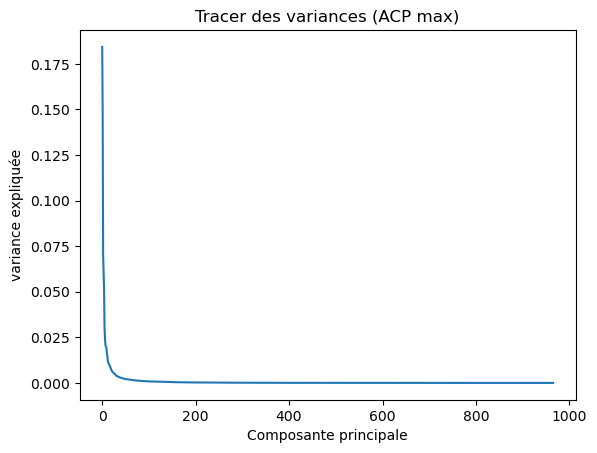

In [94]:
# 1) ACP en gardant le maximum de composantes, ajustement et tracé des variances
pca = acp_max_composantes(X_train, afficher=True)

Commentaire : 

En gardant toutes les données d'entrainement (966), on observe les variances qui s'arretent avant 200 sur l'axe de la composante principale et au délà il y'a aucune variance observée.

####  Décomposition redéfinie avec PCA(100), ajustement sur X_train puis transformation de X_train et X_test en X_train1 et X_test1.

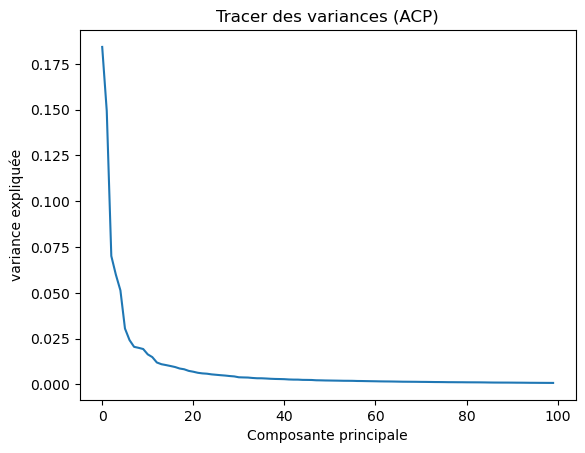


Formes après PCA(100): X_train1 (966, 100) | X_test1 (322, 100)


In [97]:
# 2) ACP avec 100 composantes, ajustement et transformation de X_train/X_test
X_train1, X_test1 = ACP_n_composants(X_train, X_test, n_components=100, tracer=True)

print('\nFormes après PCA(100): X_train1', X_train1.shape, '| X_test1', X_test1.shape)


Commentaire : Sur ce graphe, on observe les variances suite à une décomposition utilisant l'ACP en conservant cette fois ci simplement 100 composantes(les premiers + importants).

#### Réalisation de la classification sur les données de départ puis sur les nouvelles données avec la méthode du 5PPV et la distance de Manhattan puis conclusion sur le taux de reconnaissance et les temps de calcul.

- Classification sur les données de départ avec la methode du 5ppv :

In [101]:
# Classification sur les données de départ : 
tps1 = time.time() 
classification_5ppv(X_train, y_train, X_test, y_test, k=5) 
tps2 = time.time() 
print("Durée de classification sur les données de départ",tps2 - tps1) 



Matrice de confusion :
 [[  8   6   0   5   0   0   0]
 [  3  44   2   9   0   0   1]
 [  2   8   9   8   1   0   2]
 [  2  13   4 111   0   2   1]
 [  0   2   4  11   6   0   4]
 [  1   3   0   8   1   5   0]
 [  0   3   1  12   3   2  15]]
Taux de reconnaissance : 61.49%
Durée de classification sur les données de départ 1.2859203815460205


- Classification sur les nouvelles données avec la methode du 5ppv: 

In [103]:
# Classification sur les nouvelles données : 
tps1 = time.time() 
classification_5ppv(X_train1, y_train, X_test1, y_test, k=5)
tps2 = time.time() 
print("Durée de classification sur les nouvelles données",tps2 - tps1) 


Matrice de confusion :
 [[  9   7   0   2   0   0   1]
 [  2  43   5   7   0   0   2]
 [  2   6   9  11   1   0   1]
 [  1   6   4 120   0   0   2]
 [  0   3   2   9   8   0   5]
 [  0   6   0   5   0   6   1]
 [  1   2   4   8   2   1  18]]
Taux de reconnaissance : 66.15%
Durée de classification sur les nouvelles données 0.10893392562866211


- Conclusion sur le taux de reconnaissance et les temps de calcul: 

Avec la méthode de 5ppv sur les données de depart et sur les nouvelles données, on observe sur les nouvelles données non seulement un taux de reconaissance meilleur par rapport aux données de depart mais aussi un temps de calcul plus rapide. 
Cela peut s'explique par le fait que la reduction de dimension a permis à la fois de rendre la classification plus rapide et d’ameliorer un peu les performances. 
L’amélioration n'est pas enorme, mais elle laisse penser que la réduction a éliminé une partie du bruit pout conserver l’information utile. Ces résultats confirment qu’en grande dimension, le temps de calcul augmente fortement et que la performance peut en être affectée.   

---
### Reponse II 

- II.1 Les valeurs renvoyées par pca.explained_variance_ratio_ sont comprises entre 0 et 1. 
         Elles indiquent la part de variance pour chaque composante principale, 
         c’est-à-dire la quantité d’information que chaque composante apporte à la description globale des données.
  
- II.2 Formes après ACP(100): X_train1 (966, 100) | X_test1 (322, 100)
         La nouvelle dimension des données est de 100 caractéristiques par image.
  
- II.3 En observant les résultats avec ou sans ACP, on se rend compte qu’avec ACP la classification est beaucoup plus rapide et le taux de reconnaissance est légèrement meilleur par rapport au cas sans ACP.

Sans ACP :

Temps de classification : 1.275048017501831 et Taux de reconnaissance : 61.49%

Avec ACP : 

Temps de classification : 0.10796689987182617 et Taux de reconnaissance : 66.15%

---


--- 
---

---
---
## III. Analyse en composantes principales et reconstruction 

### Objectif 1 : 

Le but est de compresser les images afin qu’elle prenne moins de place en mémoire. On va donc 
définir sur X_train la façon de compresser. Puis on comprimera et décomprimera les images de
X_test afin de voir les pertes induites par la compression.. 


- a-) Définissons la décomposition en composantes principales en utilisant la fonction PCA() en conservant 50 composantes et en ajustant le modèle sur X_train.

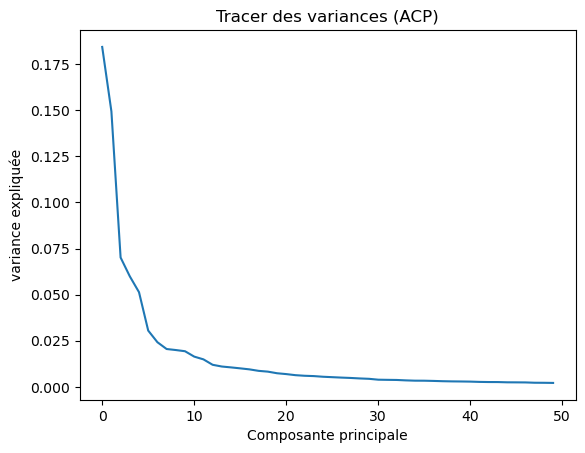


Forme de l ACP en concervant 50 composantes : 
X_train50 :  (966, 50) 
X_test50 :  (322, 50)


In [109]:
X_train50, X_test50 = ACP_n_composants(X_train, X_test, n_components=50, tracer=True)
print('\nForme de l ACP en concervant 50 composantes : \nX_train50 : ', X_train50.shape, '\nX_test50 : ', X_test50.shape)

Commentaire : Sur ce graphe, on observe les variances suite à une décomposition utilisant l'ACP en conservant simplement 50 composantes.

- b-) Récupérons les vecteurs propres en utilisant un attribut de PCA(). Redimensionnons les 
vecteurs propres en images propres (np.reshape()) de manière   pourvoir les visualiser sous
forme d’images (array de taille 50x62x47). On utilisera la fonction plot_gallery() pour l 
visualisation.

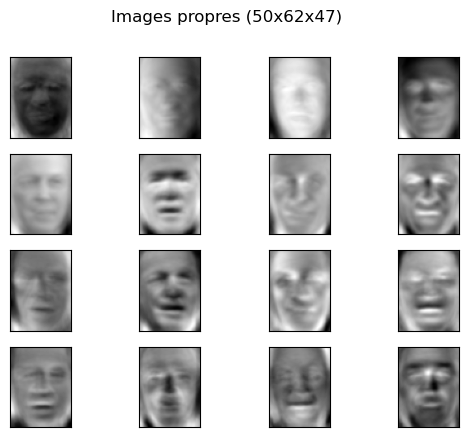

In [112]:
pca50 = PCA(n_components=50)
pca50.fit(X_train)
X_train50_redi = vecteur_propre_en_image_propre(pca50)
plotGallery(X_train50_redi, n=16, title="Images propres (50x62x47)")

---
### Reponse III.1 :

- Les vecteurs propres obtenus avec l’ACP représentent les axes principaux de variation des données, aussi appelés images propres. Ils ne correspondent pas à des images réelles mais à des combinaisons linéaires de pixels qui maximisent la variance.

- Chaque vecteur propre a la même dimension qu’une image d’origine, soit 62 × 47 = 2914. En conservant simplement 50 composantes, on obtient donc une matrice de taille (50, 2914).

---

### Objectif 2 : 

On souhaite comprimer les images de X_test afin de les transmettre en utilisant le moins de 
bande passante possible. Pour chaque image de X_test, on transmet uniquement ses 
composantes dans le nouveau système d’axe de dimension 50. L’image est ensuite reconstruite 
à l’arrivée.

- c-) Appliquons l’ACP sur les images de X_test. On appelera (X_test_comp) les nouvelles données. Cette étape constituera la compression des images.

In [116]:
X_test_comp = pca50.transform(X_test) 
print("l'ACP sur les images de X_Test donne : \nX_test_comp =", X_test_comp.shape)

l'ACP sur les images de X_Test donne : 
X_test_comp = (322, 50)


- d-) Reconstruisons (ou décompressons) les images contenues dans X_test_comp pour obtenir les 
images X_test_reconst à partir d’une des méthodes de PCA()  Afficons ensuitez les images
reconstruiteen les comparantser visuellement aux images de départ.

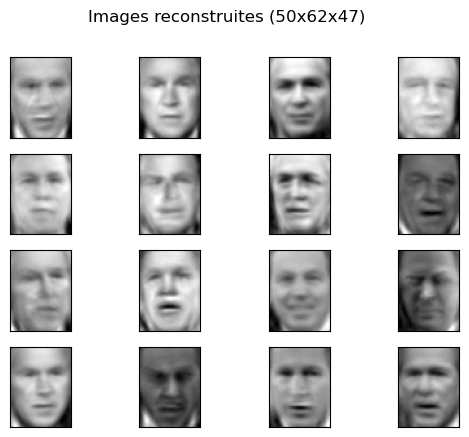

In [118]:
X_test_reconst = pca50.inverse_transform(X_test_comp) # On utilise pca.inverse_transforme()

plotGallery(X_test_reconst.reshape(-1, 62, 47), n=16, title="Images reconstruites (50x62x47)")

 Comparer visuellement aux images de départ : 

En comparant les images de départ avec les images reconstruites après compression, on voit que l’essentiel des détails est conservé. Il y a cependant un peu de flou, que l’on peut considérer comme des informations perdues, ce qui s’explique par le fait que nous n’avons utilisé que 50 composantes principales, permettant de garder seulement l’essentiel pendant la compression.

- e-) Comparons les images initiales et reconstruites de manière quantitative en faisant la moyenne des distances euclidiennes : 

In [121]:
# Methode imposée par l'enoncé 
E= (X_test_reconst -X_test)**2 
E = np.mean(np.sqrt(np.sum(E,axis=0)))
print("Moyenne des distances ecludiennes :", E)

Moyenne des distances ecludiennes : 276.34467


Commentaire : 

La moyenne des distances euclidiennes entre les images reconstruites et les images de départ est de 276. Cela confirme qu’il y a une petite différence entre les images compressées et les images originales, mais que l’essentiel des informations est conservé.

---
### Reponse III.2 :

- Comparons les tailles de X_test et X_test_comp et deduisons-en le taux de compression. 



In [124]:
taille_X_test =  X_test.size # (322x62x47)
taille_X_test_comp = X_test_comp.size  # (322x50)
taux_de_compression = taille_X_test / taille_X_test_comp  # (322x62x47)/(322x50)

print("Taille de depart :", taille_X_test, "\nTaille compressées :",taille_X_test_comp, "\ntaux de compression",taux_de_compression)

Taille de depart : 938308 
Taille compressées : 16100 
taux de compression 58.28


La taille de X_test est de 938 308 valeurs, tandis que X_test_comp ne contient que 16 100 valeurs. Le taux de compression est donc de 58.28, ce qui montre que l’ACP permet de réduire fortement le volume des données.

- Observons la taille de X_test_reconst et donnons le principe de la reconstruction des images

In [127]:
taille_X_test_reconst = X_test_reconst.size 
print("Taille des images reconstruites : ",taille_X_test_reconst)

Taille des images reconstruites :  938308


La taille des images reconstruites est la même que celle des images de départ, 938 308. Chaque image compressée est reprojetée dans l’espace d’origine avec PCA pour être reconstruite. On perd un peu de détails, mais l’essentiel de l’image est conservé.

- Pour passer de X_test_comp à X_test_reconst, on utilise la PCA à l’envers(pca.inverse) : on reprend les composantes compressées et on les remet dans l’espace original pour reconstruire les images.

---
-  f-)  On Fait varier le nombre de composantes conservées de 10 à 950 par pas de 50 puis on calcul l’erreur de reconstruction et on Affiche à la fin l’erreur de reconstruction en fonction du nombre de 
composantes. 

Text(0.5, 1.0, 'Erreur de reconstruction en fonction du nombre de composantes')

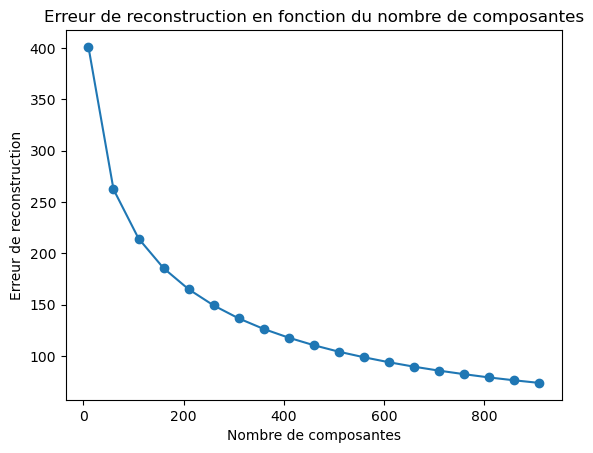

In [131]:
# On fait varier le nombre de composantes de 10 à 950 par pas de 50

composantes = list(range(10, 951, 50))
erreurs = []
for n in composantes:
    pca_n = PCA(n_components=n)
    pca_n.fit(X_train)
    
    # Compression et reconstruction des images de test
    X_test_comp = pca_n.transform(X_test)
    X_test_reconst = pca_n.inverse_transform(X_test_comp)
    
    # Erreur de reconstruction
    E = (X_test_reconst - X_test)**2
    erreur = np.mean(np.sqrt(np.sum(E, axis=0)))  # moyenne des distances euclidiennes
    erreurs.append(erreur)

plt.figure()
plt.plot(composantes, erreurs, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Erreur de reconstruction")
plt.title("Erreur de reconstruction en fonction du nombre de composantes")


Commentaire : 

On observe sur la figure que la courbe décroît : quand on augmente le nombre de composantes, l’erreur de reconstruction diminue. Ça veut dire que plus on garde de composantes principales, plus les images reconstruites se rapprochent des images de depart. Si on garde tres peu de données d'entrenements, l’erreur sera plus grande parce que beaucoup d’informations seront perdues.

- Comparons visuellement les images initiales et reconstruites à partir de 950 composantes. 

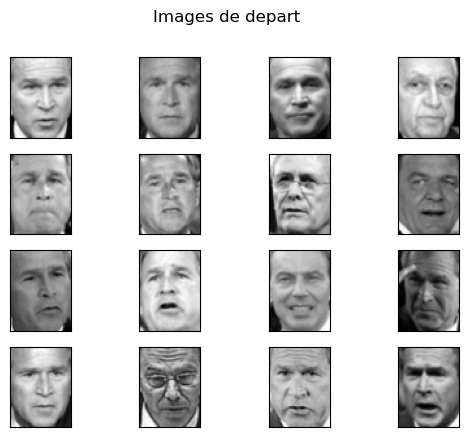

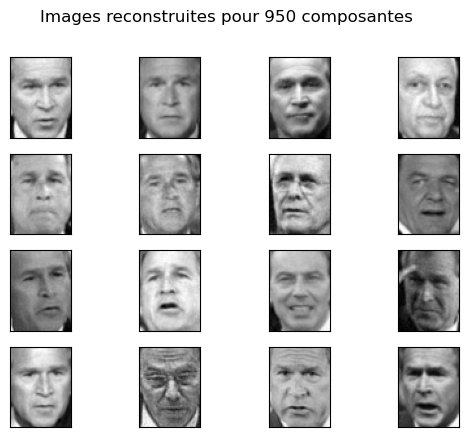

In [134]:
# Code pour repondre au 3 eme point de la question III.3
pca_950 = PCA(n_components=950)
pca_950.fit(X_train)

# Compression et reconstruction des images de test
X_test_comp_950 = pca_950.transform(X_test)
X_test_reconst_950 = pca_950.inverse_transform(X_test_comp_950)
plotGallery(X_test.reshape(-1,62,47), n=16, title="Images de depart")
plotGallery(X_test_reconst_950.reshape(-1, 62, 47), n=16, title="Images reconstruites pour 950 composantes")

---
### Reponse III.3 :

- Plus on augmente le nombre de composantes plus l’erreur de reconstruction diminue et plus l’image reconstruite se rapproche de l’original.

- Si on garde toutes les composantes, l’erreur serait quasiment nulle car on ne perdrait aucune information.

- Les images reconstruites sont presqu'identiques aux images originales. On voit très peu de différence, quasiment aucun flou ni perte de détail.

- Conclusion :

L’ACP permet de réduire le nombre de données nécessaires pour représenter les images tout en conservant l’essentiel de l’information. Plus on garde de composantes, plus la reconstruction est fidèle, et en gardant toutes les composantes, on récupère exactement les images de départ.

---
---

---
---

## Conclusion Générale 

Ce TP m’a permis de savoir comment l’ACP peut réduire la dimension des données tout en gardant l’essentiel de l’information. La classification devient plus rapide et parfois un peu plus précise quand on reduit les données d'entrainement. Pour la reconstruction, plus on garde de composantes, plus les images reconstruites ressemblent aux images de depart. Si on garde toutes les données d'entrements, on récupère exactement les images de départ. L’ACP peut etre utile pour compresser les données sans perdre beaucoup d'informations.

---
---